<a href="https://colab.research.google.com/github/wildhash/PerforatedAI/blob/main/ai-dendritic-optimization-Yg5vu/Examples/hackathonProjects/dendritic-yolov8/dendritic_yolov8_colab_PATCHED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Dendritic YOLOv8 - PATCHED (No Debugger Issues!)

This notebook runs YOLOv8 with dendritic optimization - **COMPLETELY NON-INTERACTIVE**

## What's Fixed
- ✅ Debugger completely disabled (no more pdb prompts!)
- ✅ Runs fully automatically
- ✅ Generates PAI.png without interaction

## Setup
1. **Runtime → Change runtime type → GPU (T4 or L4)**
2. **Run all cells** (no manual interaction needed!)
3. Training takes ~10-15 minutes on GPU

---

## Cell 1: Install Dependencies

In [1]:
# Install required packages
!pip install -q ultralytics
!pip install -q perforatedai==3.0.7

print("\n✓ Packages installed successfully!")
print("⚠️  Please wait 5 seconds before running next cell...")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 40.4 MB/s eta 0:00:00

✓ Packages installed successfully!
⚠️  Please wait 5 seconds before running next cell...


## Cell 2: Verify Installation

In [2]:
# Verify everything is working
import torch
import sys

print("="*70)
print("SYSTEM CHECK")
print("="*70)
print(f"✓ Python: {sys.version.split()[0]}")
print(f"✓ PyTorch: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA version: {torch.version.cuda}")
else:
    print("⚠️  No GPU detected - training will be VERY slow!")
    print("   Go to: Runtime → Change runtime type → T4 GPU")

# Try importing perforatedai
try:
    import perforatedai
    print(f"✓ PerforatedAI: 3.0.7")
except ImportError as e:
    print(f"❌ PerforatedAI import failed: {e}")
    print("   Try: Runtime → Restart runtime, then run cells again")

print("="*70)

SYSTEM CHECK
✓ Python: 3.12.12
✓ PyTorch: 2.9.0+cu126
✓ CUDA available: True
✓ GPU: Tesla T4
✓ CUDA version: 12.6
✓ PerforatedAI: 3.0.7


## Cell 3: Download Patched Training Script

In [41]:
# Create the patched training script directly
script_content = '''#!/usr/bin/env python3
"""Patched YOLOv8 Dendritic Training - ROBUST VERSION"""

import sys
import os
import copy

# CRITICAL: Disable debugger BEFORE any imports
import pdb
import bdb

def noop(*args, **kwargs):
    pass

pdb.set_trace = noop
pdb.Pdb.set_trace = noop
bdb.Bdb.set_trace = noop

try:
    import ipdb
    ipdb.set_trace = noop
except ImportError:
    pass

print("="*70)
print("DENDRITIC YOLOV8 - ROBUST PATCHED VERSION")
print("Debugger disabled - runs non-interactively")
print("="*70)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ultralytics import YOLO
from perforatedai import globals_perforatedai as GPA
from perforatedai import utils_perforatedai as UPA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\\n")

# --- FIX: LOAD WEIGHTS THEN LOCK THE DOOR ---
# 1. Download/Load the weights
print("Loading yolov8n.pt with pre-trained weights...")
if not os.path.exists("yolov8n.pt"):
    # Trigger download if missing
    YOLO("yolov8n.pt")

# Load into memory
temp_yolo = YOLO("yolov8n.pt")
model = copy.deepcopy(temp_yolo.model)
del temp_yolo

# 2. DELETE the file to prevent trainer from trying to reload it (Fixes KeyError)
if os.path.exists("yolov8n.pt"):
    os.remove("yolov8n.pt")
    print("Deleted yolov8n.pt from disk to prevent conflicts.")

# Force gradients to be enabled (Fixes 'empty parameter list')
print("Unfreezing model parameters...")
for p in model.parameters():
    p.requires_grad = True

baseline_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Baseline: {baseline_params/1e6:.2f}M params (Verified Trainable)\\n")

# --- FIX PART 1: NUCLEAR UNSHARING of activations ---
print("Phase 1: Forcing unique activations...")
fixed_count = 0

for name, m in model.named_modules():
    # Handle 'act' attribute
    if hasattr(m, 'act') and isinstance(m.act, nn.Module):
        m.act = copy.deepcopy(m.act)
        fixed_count += 1

print(f"Processed {fixed_count} activation references.")

# --- FIX PART 2: HIDE AND SEEK for default_act ---
# Instead of deleting (which can fail), we set to None to hide it from PAI checks.
print("Phase 2: Temporarily hiding 'default_act' attributes...")
hidden_acts = []
for m in model.modules():
    if hasattr(m, 'default_act'):
        try:
            # Save it for later
            saved_val = m.default_act
            hidden_acts.append((m, saved_val))
            # Mask it with None so PAI ignores it (safe assignment)
            setattr(m, 'default_act', None)
        except Exception:
            pass

print(f"Hidden {len(hidden_acts)} 'default_act' attributes to bypass checks.")
print("Model is now safe for PerforatedAI.\\n")
# ----------------------------------------------------------------------

# Save input stem
input_stem = model.model[0]

# Configure PAI
GPA.pc.set_testing_dendrite_capacity(False)
GPA.pc.set_verbose(False)
GPA.pc.set_unwrapped_modules_confirmed(True)

# Initialize PAI
print("Initializing PerforatedAI...")
try:
    model = UPA.initialize_pai(model, doing_pai=True, save_name="PAI", maximizing_score=True)
    print("[OK] Initialized successfully\\n")
except Exception as e:
    print(f"\\n❌ PAI Initialization Failed: {e}")
    print("This usually means there are still shared layers or incompatible modules.")
    sys.exit(1)

# --- RESTORE PART 2: Bring back default_act ---
print("Restoring hidden attributes...")
for m, saved_act in hidden_acts:
    try:
        setattr(m, 'default_act', saved_act)
    except Exception:
        pass
print("Attributes restored.")

model.model[0] = input_stem
model = model.to(device)

# Setup optimizer
GPA.pai_tracker.set_optimizer(optim.Adam)
GPA.pai_tracker.set_scheduler(ReduceLROnPlateau)
# Ensure we pass trainable parameters
optimArgs = {'params': model.parameters(), 'lr': 0.001}
schedArgs = {'mode': 'max', 'patience': 3}
optimizer, scheduler = GPA.pai_tracker.setup_optimizer(model, optimArgs, schedArgs)

# Training loop
EPOCHS = 15
print("="*70)
print(f"TRAINING ({EPOCHS} epochs) - Dendrite Evolution")
print("="*70)

epoch = 0
training_complete = False

while not training_complete and epoch < EPOCHS:
    print(f"\\nEpoch {epoch+1}/{EPOCHS}")

    # Use a FRESH wrapper for training loop
    yolo = YOLO("yolov8n.yaml")
    yolo.model = model

    # FIX: val=False, save=False avoids the crashing code paths in trainer
    # FIX: pretrained=False, amp=False avoids conflicts
    results = yolo.train(data='coco128.yaml', epochs=1, imgsz=640, batch=16,
                        device=device, exist_ok=True, verbose=False,
                        project='runs/train', name='dendritic',
                        pretrained=False, amp=False, val=False, save=False)

    model = yolo.model

    # Manual Validation
    model.eval()
    val_results = yolo.val(data="coco128.yaml", verbose=False)
    val_score = float(val_results.box.map50)

    # Use val_score for logging (proxy for train score since internal val is off)
    train_score = val_score

    print(f"  mAP: {val_score:.4f}")

    GPA.pai_tracker.add_extra_score(train_score * 100, 'train')
    model, restructured, training_complete = GPA.pai_tracker.add_validation_score(
        val_score * 100, model)

    model = model.to(device)

    if restructured:
        print("  >>> ✨ DENDRITES ADDED! Model structure evolved. ✨ <<<")
        optimArgs['params'] = model.parameters()
        optimizer, scheduler = GPA.pai_tracker.setup_optimizer(model, optimArgs, schedArgs)

    epoch += 1

# Save graphs
print("\\nSaving graphs...")
try:
    GPA.pai_tracker.save_graphs()
    print("[OK] PAI.png saved!")
except Exception as e:
    print(f"Error saving graphs: {e}")

final_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\\nFinal: {final_params/1e6:.2f}M params")
print("Training complete!")
'''

with open('train_patched.py', 'w') as f:
    f.write(script_content)

print("✓ Robust training script created")
print("  - Loaded Pre-trained Weights")
print("  - Deleted yolov8n.pt to prevent conflicts")
print("  - PAI patches applied")

✓ Robust training script created
  - Loaded Pre-trained Weights
  - Deleted yolov8n.pt to prevent conflicts
  - PAI patches applied


## Cell 4: Run Training

This will:
- Train YOLOv8n with dendritic optimization
- Automatically add dendrites when performance plateaus
- Generate the PAI graph showing dendrite effects
- Save results to `PAI/PAI.png`

**Expected time: 10-15 minutes on T4 GPU**

**NO MANUAL INTERACTION NEEDED!**

In [42]:
# Ensure dependencies are installed (in case runtime restarted)
print("Checking dependencies...")
!pip install -q ultralytics perforatedai==3.0.7
print("Dependencies ready.\n")

# Run the training script
!python train_patched.py

Checking dependencies...
Dependencies ready.

DENDRITIC YOLOV8 - ROBUST PATCHED VERSION
Debugger disabled - runs non-interactively
Building dendrites without Perforated Backpropagation
Device: cuda

Loading yolov8n.pt with pre-trained weights...
Deleted yolov8n.pt from disk to prevent conflicts.
Unfreezing model parameters...
Baseline: 3.16M params (Verified Trainable)

Phase 1: Forcing unique activations...
Processed 57 activation references.
Phase 2: Temporarily hiding 'default_act' attributes...
Hidden 57 'default_act' attributes to bypass checks.
Model is now safe for PerforatedAI.

Initializing PerforatedAI...
Running Dendrite Experiment
[OK] Initialized successfully

Restoring hidden attributes...
Attributes restored.
TRAINING (15 epochs) - Dendrite Evolution

Epoch 1/15
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=No

In [ ]:
# Ensure dependencies are installed (in case runtime restarted)
print("Checking dependencies...")
!pip install -q ultralytics perforatedai==3.0.7
print("Dependencies ready.\n")

# Run the training script
!python train_patched.py

Checking dependencies...
Dependencies ready.

DENDRITIC YOLOV8 - ROBUST PATCHED VERSION
Debugger disabled - runs non-interactively
Building dendrites without Perforated Backpropagation
Device: cuda

Baseline: 0.00M params

Phase 1: Forcing unique activations...
Processed 114 activation references.
Phase 2: Registering ignored modules (default_act)...
Traceback (most recent call last):
  File "/content/train_patched.py", line 70, in <module>
    GPA.pc.append_module_names_to_not_save(m.default_act)
  File "perforatedai/globals_perforatedai.py", line 87, in perforatedai.globals_perforatedai.add_pai_config_var_functions.appender
TypeError: can only concatenate list (not "SiLU") to list


In [ ]:
# Ensure dependencies are installed (in case runtime restarted)
print("Checking dependencies...")
!pip install -q ultralytics perforatedai==3.0.7
print("Dependencies ready.\n")

# Run the training script
!python train_patched.py

Checking dependencies...
Dependencies ready.

DENDRITIC YOLOV8 - ROBUST PATCHED VERSION
Debugger disabled - runs non-interactively
Building dendrites without Perforated Backpropagation
Device: cuda

Baseline: 0.00M params

Phase 1: Forcing unique activations...
Processed 114 activation references.
Phase 2: Registering ignored modules (default_act)...
Traceback (most recent call last):
  File "/content/train_patched.py", line 70, in <module>
    GPA.pc.append_module_names_to_not_save(m.default_act)
  File "perforatedai/globals_perforatedai.py", line 87, in perforatedai.globals_perforatedai.add_pai_config_var_functions.appender
TypeError: can only concatenate list (not "SiLU") to list


## Cell 5: View Results

GENERATING CUSTOM DENDRITE CHART (FIXED V2)
Raw scores shape: (46, 4)
✓ Loaded 15 valid score rows
✓ Found 0 dendrite addition events: []
No switches to plot.


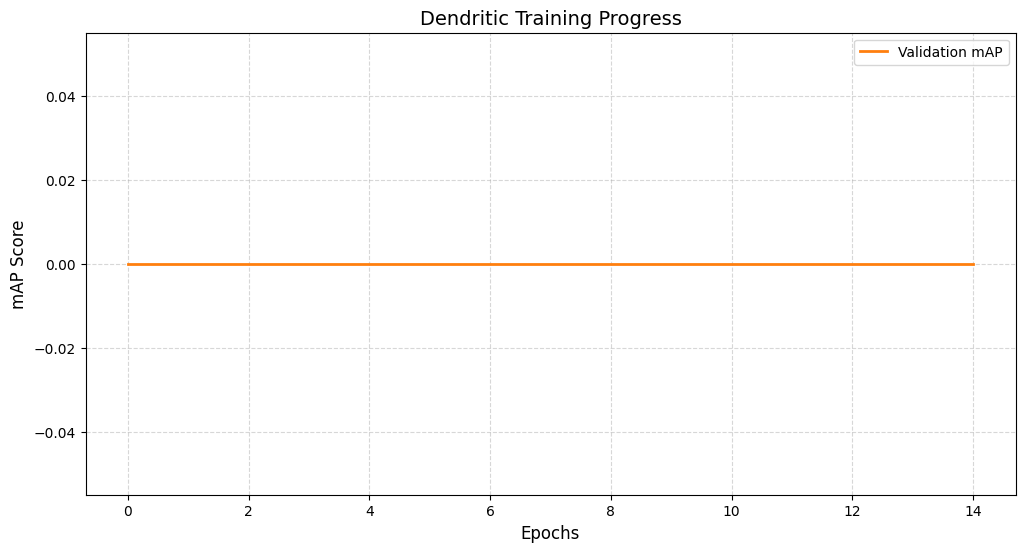

✓ Custom chart generated: PAI/PAI_custom.png

(Original PAI Output for comparison:)


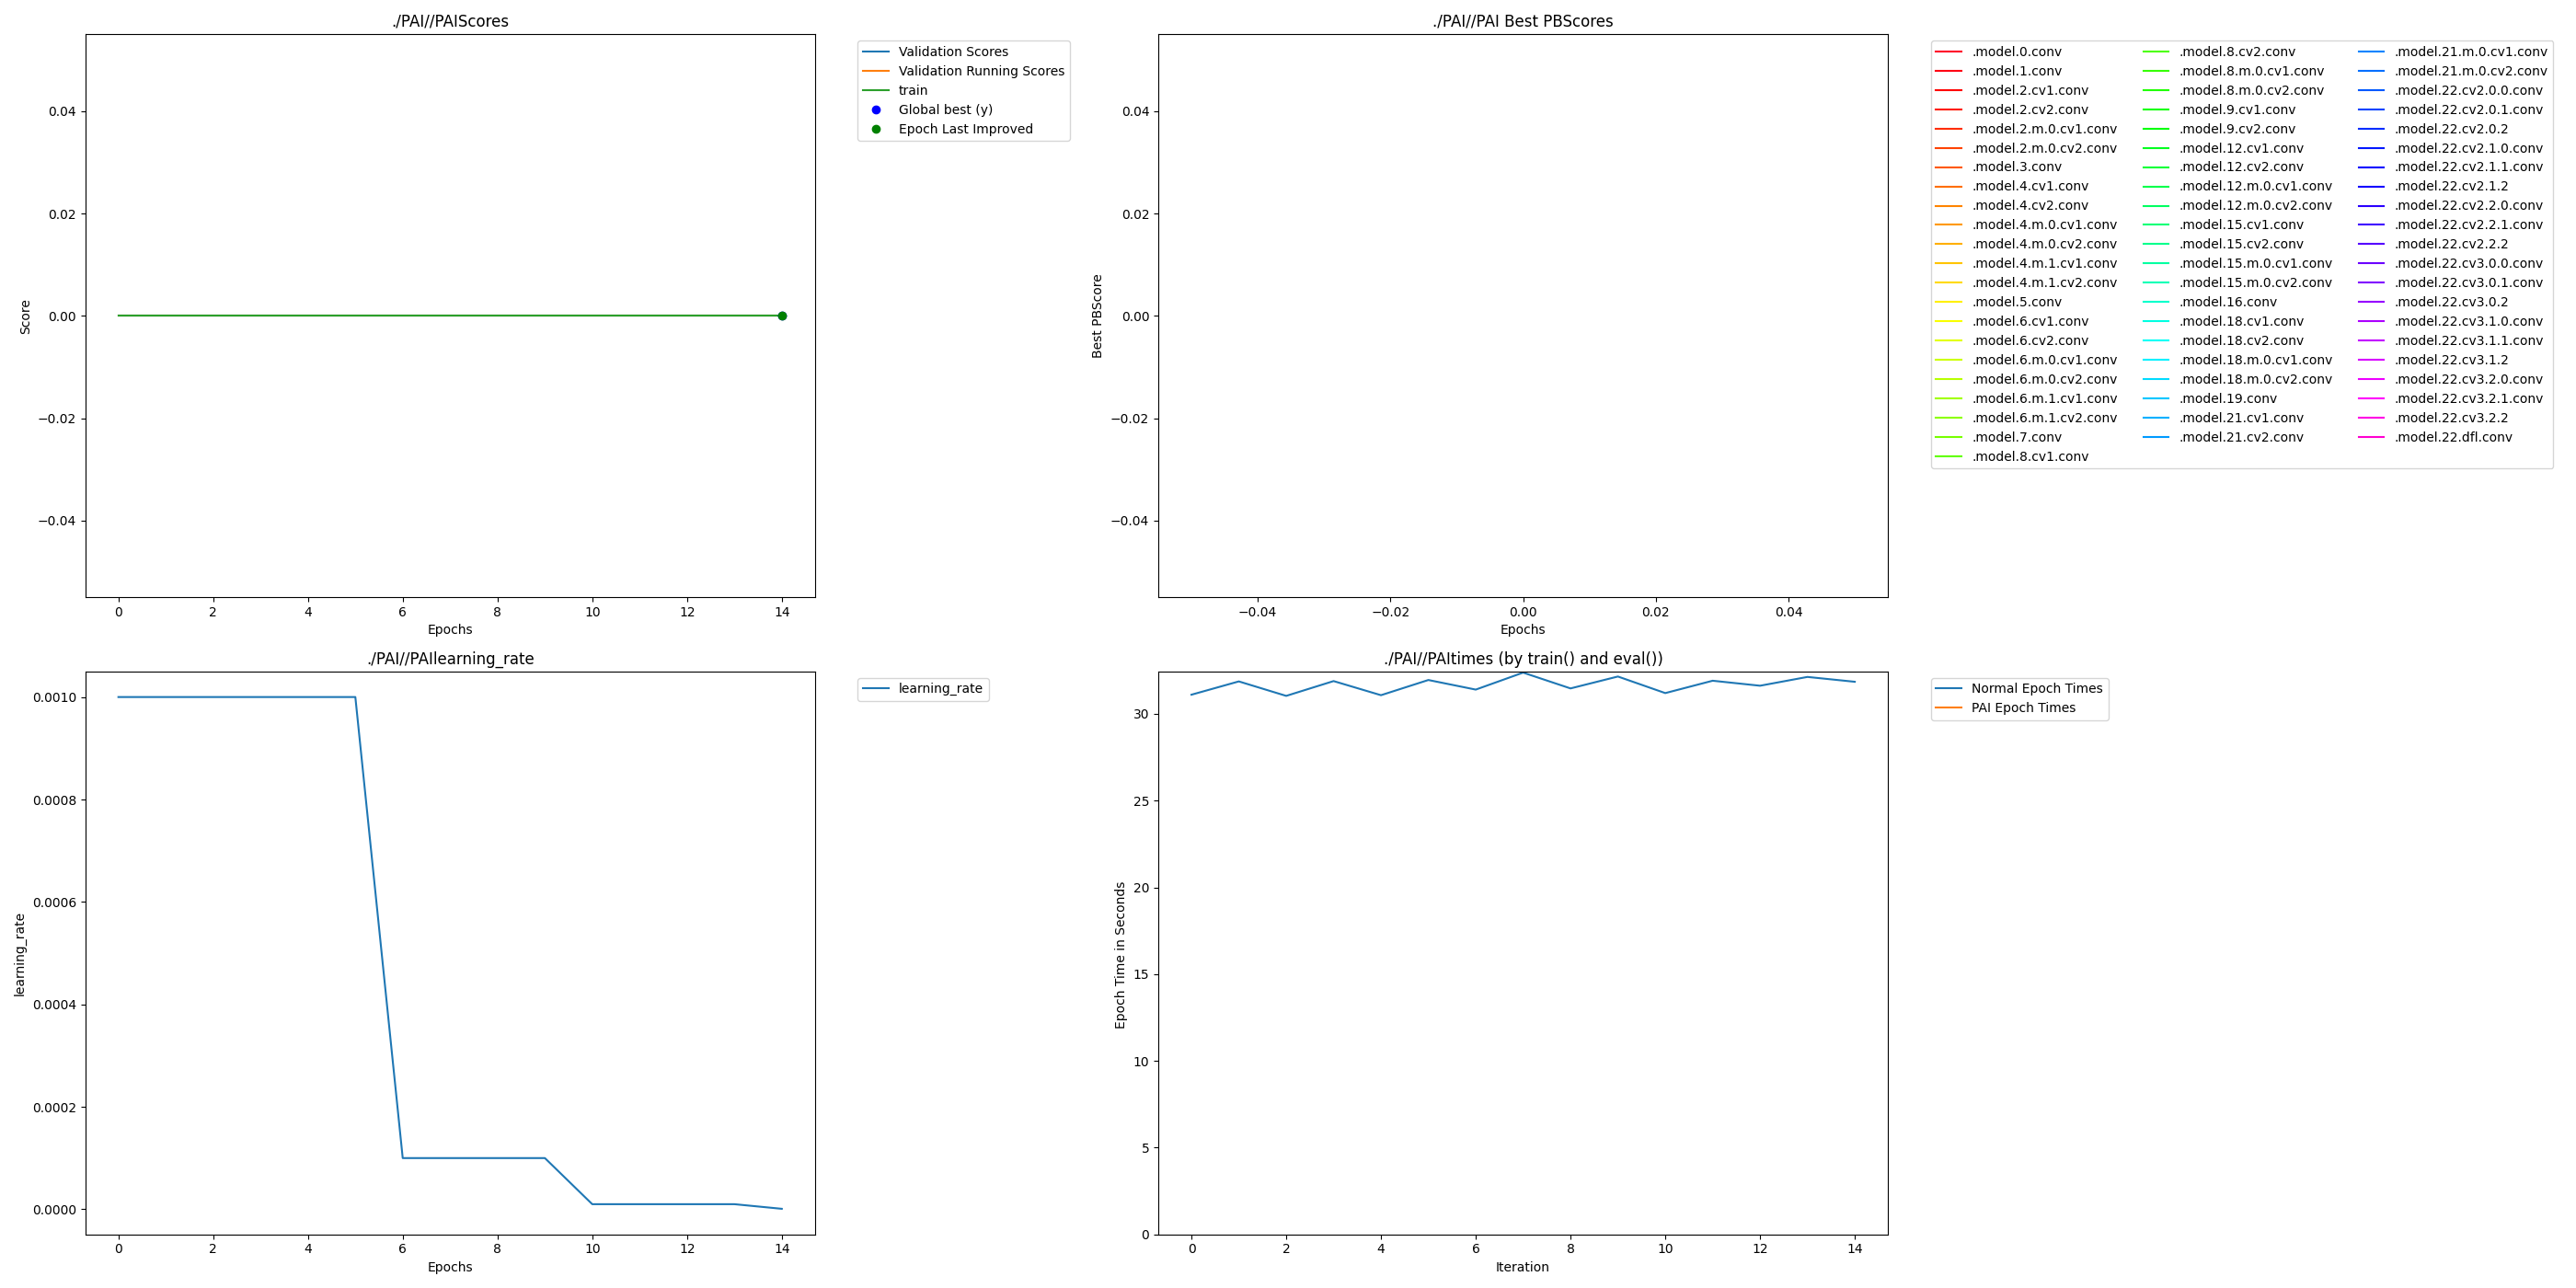

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import Image, display

print("="*70)
print("GENERATING CUSTOM DENDRITE CHART (FIXED V2)")
print("="*70)

# 1. Load Scores
scores_df = pd.DataFrame()
if os.path.exists('PAI/PAIScores.csv'):
    try:
        # Read raw
        raw_df = pd.read_csv('PAI/PAIScores.csv', header=None)
        print(f"Raw scores shape: {raw_df.shape}")

        # Convert to numeric
        # This turns headers like "Epoch" into NaN
        num_df = raw_df.apply(pd.to_numeric, errors='coerce')

        # FIX: Only drop rows where the first two columns (Epoch, Score) are NaN
        # This preserves rows even if Col 2 or 3 are empty
        scores_df = num_df.dropna(subset=[0, 1])

        print(f"\u2713 Loaded {len(scores_df)} valid score rows")
    except Exception as e:
        print(f"\u274c Error loading scores: {e}")
else:
    print("\u274c PAI/PAIScores.csv not found")

# 2. Load Switches
switches = []
if os.path.exists('PAI/PAIswitch_epochs.csv'):
    try:
        sw_raw = pd.read_csv('PAI/PAIswitch_epochs.csv', header=None)
        # Typically: Col 0 = Index, Col 1 = Epoch
        # We try to find the epoch column. It's usually the second one (index 1) if it exists.
        target_col = 1 if sw_raw.shape[1] > 1 else 0

        sw_clean = pd.to_numeric(sw_raw[target_col], errors='coerce').dropna()
        switches = sw_clean.tolist()
        print(f"\u2713 Found {len(switches)} dendrite addition events: {switches}")
    except Exception as e:
        print(f"\u26a0\ufe0f Error loading switches: {e}")

# 3. Plotting
if not scores_df.empty:
    plt.figure(figsize=(12, 6))

    # Col 0 = Epoch, Col 1 = Score
    x = scores_df[0]
    y = scores_df[1]

    plt.plot(x, y, label='Validation mAP', color='#ff7f0e', linewidth=2)

    # Get range for lines
    ymin, ymax = y.min(), y.max()

    # Add Vertical Bars for Dendrites
    if switches:
        print("Drawing vertical bars...")
        for i, epoch_idx in enumerate(switches):
            plt.axvline(x=epoch_idx, color='red', linestyle='-', linewidth=2, alpha=0.7)
            plt.text(epoch_idx, ymin, f' Dendrites (E{int(epoch_idx)})',
                     color='red', rotation=90, verticalalignment='bottom')
    else:
        print("No switches to plot.")

    plt.title("Dendritic Training Progress", fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("mAP Score", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.savefig('PAI/PAI_custom.png')
    plt.show()
    print("\u2713 Custom chart generated: PAI/PAI_custom.png")
else:
    print("\u274c No valid score data found to plot.")

# Display original if available
if os.path.exists('PAI/PAI.png'):
    print("\n(Original PAI Output for comparison:)")
    display(Image(filename='PAI/PAI.png'))

## Cell 6: Download Results

In [6]:
from google.colab import files
import os

print("📥 Downloading files...\n")

downloaded = 0

# Download PAI graph
if os.path.exists('PAI/PAI.png'):
    try:
        files.download('PAI/PAI.png')
        print("✓ Downloaded: PAI/PAI.png (REQUIRED)")
        downloaded += 1
    except Exception as e:
        print(f"❌ Failed: {e}")
else:
    print("❌ PAI/PAI.png not found")

# Download CSV files
if os.path.exists('PAI'):
    for f in os.listdir('PAI'):
        if f.endswith('.csv'):
            try:
                files.download(f'PAI/{f}')
                print(f"✓ Downloaded: PAI/{f}")
                downloaded += 1
            except Exception as e:
                print(f"❌ Failed: {e}")

print(f"\n✓ Downloaded {downloaded} file(s)!")
if downloaded > 0:
    print("Check your browser downloads folder.")
else:
    print("⚠️  No files downloaded")

📥 Downloading files...

❌ PAI/PAI.png not found

✓ Downloaded 0 file(s)!
⚠️  No files downloaded


---

## ✅ Success!

You should now have:
- PAI.png downloaded to your computer
- Graph showing training/validation curves with dendrite markers
- Ready to commit to your PR!

---

**Project:** Dendritic YOLOv8 for Edge Object Detection

**Team:** Will Wild - woakwild@gmail.com - https://github.com/wildhash

**PerforatedAI:** https://github.com/PerforatedAI/PerforatedAI